# 01 — Macro & Economic State

**Chain position:** `Macro` → Risk → Rates → Global Equity → India → Companies

This is the first link. Everything downstream is conditioned on the answer here: *what
economic regime are we actually in, and how is it transmitting into asset prices?*

The notebook works in two layers, because they answer different questions:

| Layer | Source | Frequency | What it tells you |
|---|---|---|---|
| **Structural** | World Bank | Annual, publishes with a ~1 year lag | Where growth and inflation have *settled* |
| **Nowcast** | Commodity & FX markets | Daily | What is happening to the transmission channel *now* |

The World Bank layer cannot tell you about this month — it is the slow-moving backdrop.
The commodity layer is the live read. The regime call at the end uses both and says
which parts are stale.

> **On sources:** FRED was tested for this project and is dead — all nine series timed
> out on two separate attempts. It is replaced by the US Treasury daily curve (notebook
> 03) and the World Bank API here. Yahoo's Indian sector indices were also rejected
> (~55% missing) in favour of NSE's own endpoint (notebook 05).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard,
                 indicators as ind, fundamentals as fnd, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

mkt v1.0.0 | run 2026-09-09 10:45 | REFRESH=False | cache=G:\stock market analysis\data\cache


## 1. Source health

Nothing below is trustworthy if the feeds are not. This table runs first, every time.

A source is `OK` only if it returned rows **and** its as-of date is inside the staleness
tolerance for its type. Anything else is flagged loudly rather than quietly serving a
week-old number as though it were today's.

In [2]:
health = fetch.health_check()
display(health.style.map(
    lambda v: ("color:#2f855a;font-weight:600" if v == "OK" else
               "color:#c53030;font-weight:600" if v in ("FAILED", "STALE") else ""),
    subset=["status"]).format({"age_days": "{:.0f}", "secs": "{:.2f}"}))

n_ok = int((health["status"] == "OK").sum())
if n_ok < len(health):
    print("\nDegraded sources:")
    for _, r in health[health["status"] != "OK"].iterrows():
        print(f"  - {r['source']}: {r['status']}  {r['note']}")
else:
    print(f"All {n_ok} sources healthy.")

Source health: 8/8 OK  (checked 2026-09-09 10:45)


,source,status,rows,as_of,age_days,tolerance_days,secs,note
0,NSE allIndices,OK,139,2026-09-09 10:41:00,0,5,0.32,
1,NSE marketStatus,OK,6,2026-09-09 10:44:00,0,5,0.38,
2,NSE FII/DII,OK,2,2026-09-08 00:00:00,1,5,0.10,
3,US Treasury curve,OK,1421,2026-09-08 00:00:00,1,7,8.42,
4,World Bank GDP,OK,21,2025,365,800,0.02,
5,yfinance ^NSEI,OK,23,2026-09-09 00:00:00,0,5,1.98,
6,yfinance ^GSPC,OK,21,2026-09-08 00:00:00,1,5,0.22,
7,yfinance ^VIX,OK,22,2026-09-08 00:00:00,1,5,0.35,


All 8 sources healthy.


### Why the as-of dates differ

Markets close at different times, and this project never pretends otherwise. On a
weekday evening in India, the NSE has settled and the US has not — so the NSE figure is
today's and the S&P figure is yesterday's. Every frame in this project carries its own
as-of stamp for exactly this reason, and alignment never forward-fills a series past its
own last real observation.

## 2. Structural layer — growth and inflation, 2005 → now

Real GDP growth and CPI inflation for India, the US, China, the Euro Area and Japan.
The vertical markers are the chronological crisis chain the macro story runs through.

In [3]:
gdp = fetch.worldbank("NY.GDP.MKTP.KD.ZG")
cpi = fetch.worldbank("FP.CPI.TOTL.ZG")
gdppc = fetch.worldbank("NY.GDP.PCAP.CD")

print(f"GDP growth: {gdp.shape[0]} years x {gdp.shape[1]} economies, "
      f"latest full year = {int(gdp.dropna(how='all').index.max())}")
display(gdp.tail(12).round(2))

GDP growth: 21 years x 5 economies, latest full year = 2025


,China,Euro Area,India,Japan,United States
year,,,,,
2014,7.46,1.63,7.41,0.91,2.52
2015,6.98,2.37,8.00,1.80,2.95
2016,6.77,1.92,8.26,0.70,1.82
2017,6.89,2.82,6.80,1.62,2.46
2018,6.76,2.05,6.45,0.83,2.97
2019,6.07,1.88,3.87,-0.31,2.58
2020,2.34,-5.58,-5.78,-4.28,-2.08
2021,8.57,6.38,9.69,3.56,6.15
2022,3.13,3.56,7.61,1.33,2.52


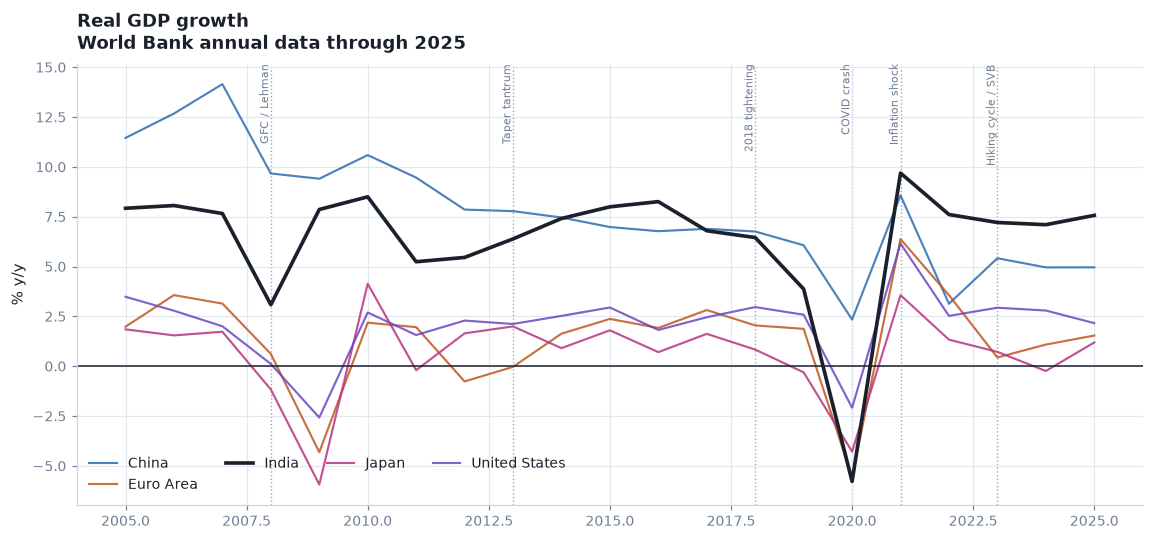

In [4]:
def macro_chart(df, title, ylabel, zero_line=False):
    fig, ax = plt.subplots(figsize=(12.5, 5.2))
    viz.line(df, ax=ax, title_=title,
             sub=f"World Bank annual data through {int(df.dropna(how='all').index.max())}",
             ylabel=ylabel, highlight="India")
    if zero_line:
        ax.axhline(0, color=viz.INK, lw=1)
    ax.set_xlabel("")
    return fig, ax

fig, ax = macro_chart(gdp, "Real GDP growth", "% y/y", zero_line=True)
# The crisis chain is drawn on the annual axis by year, not by exact date.
for date, label in config.CRISIS_CHAIN:
    yr = pd.Timestamp(date).year
    if gdp.index.min() <= yr <= gdp.index.max():
        ax.axvline(yr, color=viz.MUTED, ls=":", lw=0.9, alpha=0.7, zorder=0)
        ax.annotate(label, xy=(yr, ax.get_ylim()[1]), fontsize=7.5, color=viz.MUTED,
                    rotation=90, ha="right", va="top")
viz.save(fig, "01_gdp_growth"); plt.show()

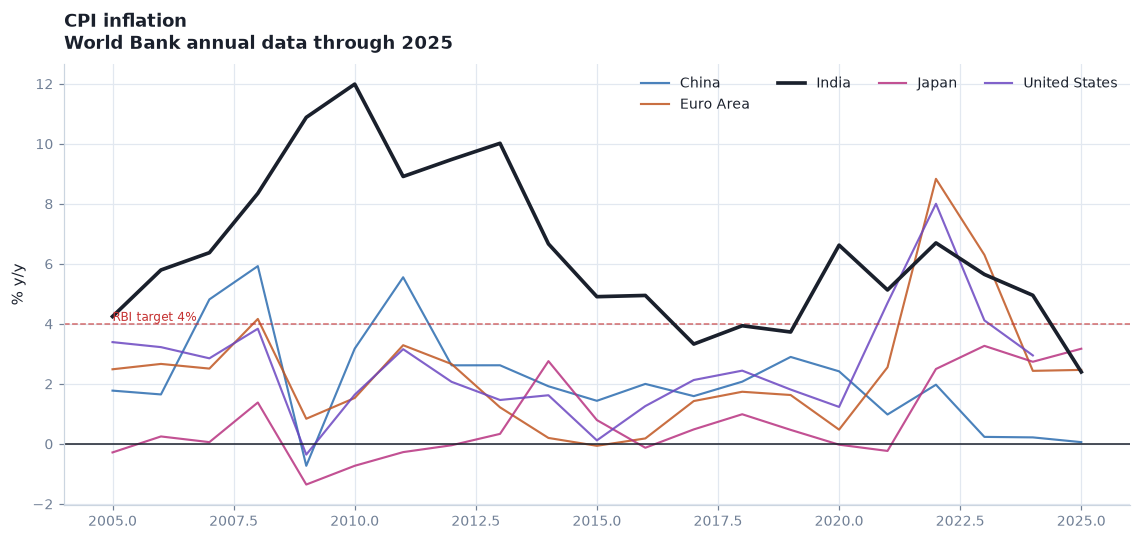

In [5]:
fig, ax = macro_chart(cpi, "CPI inflation", "% y/y", zero_line=True)
ax.axhline(4, color=viz.NEG, ls="--", lw=1.0, alpha=0.7)
ax.annotate("RBI target 4%", xy=(cpi.index.min(), 4), fontsize=8,
            color=viz.NEG, va="bottom")
viz.save(fig, "01_inflation"); plt.show()

## 3. Growth–inflation quadrant

The standard macro framing: where each economy sits on growth versus inflation, and how
it moved over the last three years. The reference lines are each series' own long-run
median, so "high" means high *for that economy* — 6% growth is weak for India and
extraordinary for Japan.

,GDP growth %,CPI %,growth vs own median,inflation vs own median,regime
China,4.96,0.06,-2.50,-1.91,Disinflationary slowdown
Euro Area,1.54,2.47,-0.38,0.03,"Stagflation (weak growth, hot prices)"
India,7.57,2.40,0.16,-3.40,"Goldilocks (growth, cooling prices)"
Japan,1.19,3.17,0.00,2.84,Reflation (growth + inflation)


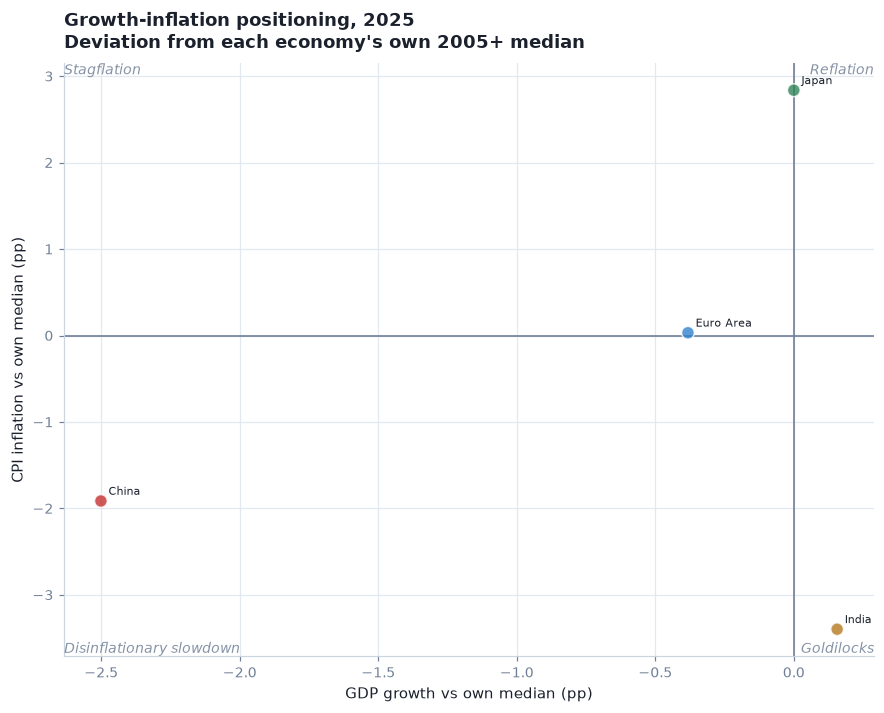

In [6]:
latest_yr = int(gdp.dropna(how="all").index.max())
g_now, i_now = gdp.loc[latest_yr], cpi.loc[latest_yr]
g_med, i_med = gdp.median(), cpi.median()

quad = pd.DataFrame({
    "GDP growth %": g_now, "CPI %": i_now,
    "growth vs own median": g_now - g_med,
    "inflation vs own median": i_now - i_med,
}).dropna()

def label_quadrant(row):
    hot_g = row["growth vs own median"] >= 0
    hot_i = row["inflation vs own median"] >= 0
    return ("Reflation (growth + inflation)" if hot_g and hot_i else
            "Goldilocks (growth, cooling prices)" if hot_g else
            "Stagflation (weak growth, hot prices)" if hot_i else
            "Disinflationary slowdown")

quad["regime"] = quad.apply(label_quadrant, axis=1)
display(quad.round(2))

fig, ax = plt.subplots(figsize=(9.5, 7))
viz.quadrant(quad["growth vs own median"], quad["inflation vs own median"], ax=ax,
             title_=f"Growth-inflation positioning, {latest_yr}",
             sub="Deviation from each economy's own 2005+ median",
             xlabel="GDP growth vs own median (pp)",
             ylabel="CPI inflation vs own median (pp)",
             quad_names=("Reflation", "Stagflation", "Disinflationary slowdown", "Goldilocks"))
viz.save(fig, "01_growth_inflation_quadrant"); plt.show()

## 4. Nowcast layer — the transmission channel

Annual data cannot tell you about this week. The dollar, crude, gold and copper can:
they are the channel through which the global macro state reaches Indian equities.

- **DXY** — a strong dollar tightens global financial conditions and pressures EM flows
- **Crude** — India imports ~85% of its oil; it is a direct terms-of-trade and CPI input
- **Copper/gold** — the classic growth-versus-fear ratio
- **USDINR** — the currency leg that converts global returns into rupee returns

These trade on different calendars, so they are aligned explicitly before anything is
computed from them.

In [7]:
macro_frames, macro_failed = fetch.price_histories(
    list(config.MACRO_TICKERS), period=config.LONG_HISTORY_PERIOD)
if macro_failed:
    print("Dropped (reported, not hidden):", macro_failed)

macro_px = align.align_multi(macro_frames, calendar="B", max_gap=3)
macro_px.columns = [config.MACRO_TICKERS.get(c, c) for c in macro_px.columns]

nan_rate = align.assert_alignment(macro_px, max_nan_pct=8.0, label="macro transmission")
print(f"Post-alignment NaN rate: {nan_rate}%  (trap #1 guard passed)")
display(align.coverage_report(macro_px))

  fetched 7/7 tickers in 3s
Post-alignment NaN rate: 0.06%  (trap #1 guard passed)


,series,first_obs,last_obs,n_obs,n_slots,nan_pct_in_window,max_gap_days,lag_days
0,USDINR,2006-09-11,2026-09-08,5203,5217,0.27,21,1
1,Brent Crude,2007-07-30,2026-09-09,4979,4988,0.18,14,0
2,US Dollar Index,2006-09-11,2026-09-09,5218,5218,0.00,3,0
3,WTI Crude,2006-09-11,2026-09-09,5218,5218,0.00,3,0
4,Gold,2006-09-11,2026-09-09,5218,5218,0.00,3,0
5,Copper,2006-09-11,2026-09-09,5218,5218,0.00,3,0
6,Natural Gas,2006-09-11,2026-09-09,5218,5218,0.00,3,0


In [8]:
asof = align.describe_asof(macro_px)
print("Per-series as-of stamps -- note the spread; these are NOT all the same day:")
display(asof)

Per-series as-of stamps -- note the spread; these are NOT all the same day:


,series,as_of,value,lag_days
0,US Dollar Index,2026-09-09,98.74,0
1,WTI Crude,2026-09-09,94.03,0
2,Brent Crude,2026-09-09,99.07,0
3,Gold,2026-09-09,"4,425.50",0
4,Copper,2026-09-09,6.77,0
5,Natural Gas,2026-09-09,2.88,0
6,USDINR,2026-09-08,94.49,1


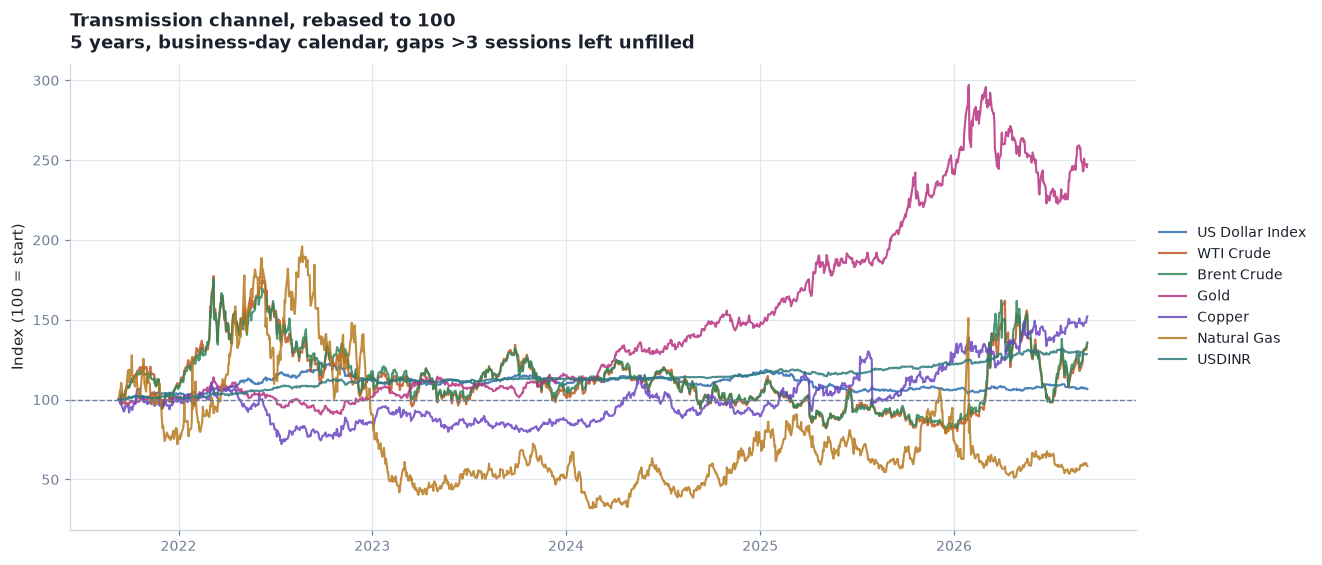

In [9]:
recent = macro_px.loc[macro_px.index >= macro_px.index.max() - pd.Timedelta(days=365*5)]
reb = align.rebase(recent.dropna(how="all"), 100)

fig, ax = plt.subplots(figsize=(12.5, 5.5))
viz.line(reb, ax=ax, title_="Transmission channel, rebased to 100",
         sub="5 years, business-day calendar, gaps >3 sessions left unfilled",
         ylabel="Index (100 = start)", legend_out=True)
ax.axhline(100, color=viz.MUTED, lw=0.9, ls="--")
viz.save(fig, "01_transmission_rebased"); plt.show()

In [10]:
rows = []
for c in macro_px.columns:
    s = macro_px[c].dropna()
    if s.empty:
        continue
    r = ind.return_table(s)
    r["level"] = s.iloc[-1]
    r["as_of"] = s.index[-1].date()
    r["pctile_10y"] = ind.percentile_rank(s.tail(2520))
    rows.append(pd.Series(r, name=c))

macro_state = pd.DataFrame(rows)[
    ["level", "as_of", "1M_%", "3M_%", "YTD_%", "1Y_%", "pctile_10y", "Vol_%"]]
print("Macro state table -- percentile is vs the last 10 years of that series")
display(macro_state.round(2))

Macro state table -- percentile is vs the last 10 years of that series


,level,as_of,1M_%,3M_%,YTD_%,1Y_%,pctile_10y,Vol_%
US Dollar Index,98.74,2026-09-09,-1.08,-1.21,0.46,0.97,53.33,4.69
WTI Crude,94.03,2026-09-09,14.49,4.44,63.76,50.14,93.65,49.58
Brent Crude,99.07,2026-09-09,12.94,6.41,62.81,49.22,93.45,53.44
Gold,"4,425.50",2026-09-09,1.46,7.72,2.31,21.47,95.12,23.70
Copper,6.77,2026-09-09,2.59,8.27,20.17,50.31,100.00,21.00
Natural Gas,2.88,2026-09-09,3.11,-9.54,-21.84,-7.57,47.50,34.74
USDINR,94.49,2026-09-08,-0.86,-1.25,5.26,7.15,96.51,7.94


### Copper/gold — the growth-versus-fear ratio

Copper is priced by industrial demand, gold by fear and real rates. The ratio rising
means the market is paying up for growth; falling means it is paying up for protection.
It is a cleaner cyclical read than either leg alone.

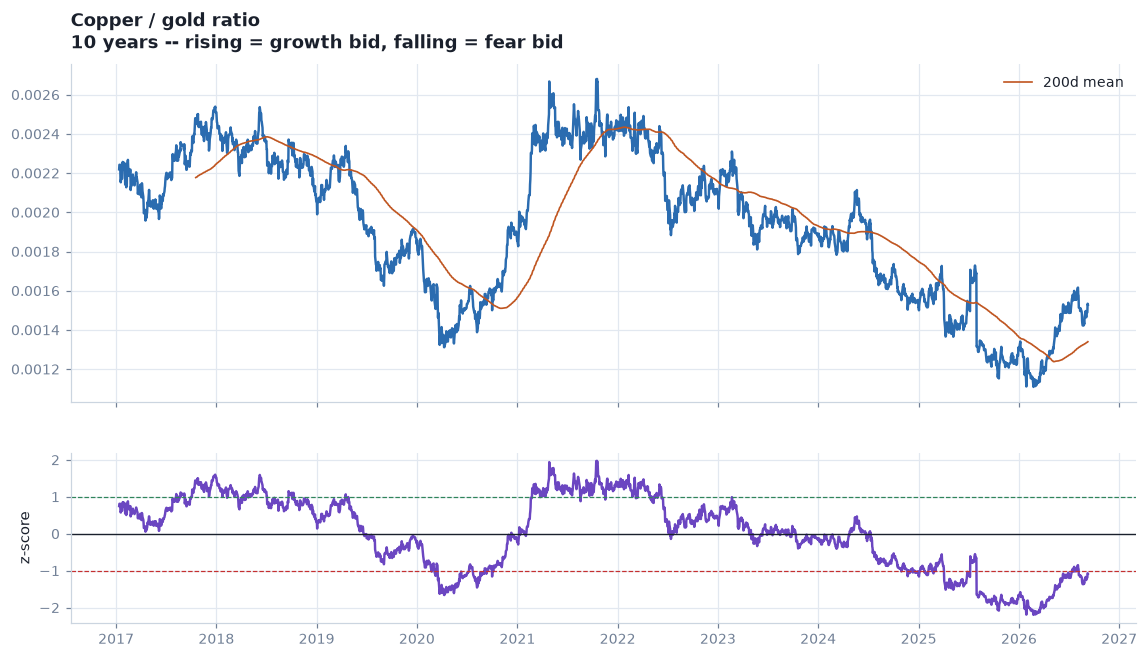

Copper/gold = 0.00153 | 10y percentile 18 | z-score -1.08 | as of 2026-09-09


In [11]:
cg = (macro_px["Copper"] / macro_px["Gold"]).dropna()
cg_z = ind.zscore(cg.tail(2520))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12.5, 6.6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a1.plot(cg.tail(2520).index, cg.tail(2520).values, color=viz.PALETTE[0])
a1.plot(cg.tail(2520).index, cg.tail(2520).rolling(200).mean(),
        color=viz.PALETTE[1], lw=1.1, label="200d mean")
viz.title(a1, "Copper / gold ratio", "10 years -- rising = growth bid, falling = fear bid")
a1.legend()
a2.plot(cg_z.index, cg_z.values, color=viz.PALETTE[4])
a2.axhline(0, color=viz.INK, lw=0.9)
a2.axhline(1, color=viz.POS, ls="--", lw=0.8); a2.axhline(-1, color=viz.NEG, ls="--", lw=0.8)
a2.set_ylabel("z-score")
viz.save(fig, "01_copper_gold"); plt.show()

cg_now, cg_pct = float(cg.iloc[-1]), ind.percentile_rank(cg.tail(2520))
print(f"Copper/gold = {cg_now:.5f} | 10y percentile {cg_pct:.0f} | "
      f"z-score {float(cg_z.iloc[-1]):+.2f} | as of {cg.index[-1].date()}")

## 5. Regime call

Two components, kept separate so you can see which one is driving the label:

**Structural** (World Bank, lags ~1 year) — India's growth and inflation against their
own long-run medians.

**Nowcast** (daily markets) — four signals, each scored −1/0/+1 for growth-friendliness:
copper/gold trend, the dollar's direction, crude's level, and the rupee's direction.

In [12]:
def trend_score(s, window=126):
    """+1 if the series is above its own trend and rising, -1 if the opposite."""
    s = s.dropna()
    if len(s) < window + 5:
        return 0.0
    ma = s.rolling(window).mean()
    above = s.iloc[-1] > ma.iloc[-1]
    rising = ma.iloc[-1] > ma.iloc[-21]
    return float(above) + float(rising) - 1.0

sig = {}
sig["copper/gold"]  = trend_score(cg)                                   # growth bid
sig["dollar (inv)"] = -trend_score(macro_px["US Dollar Index"])         # strong USD tightens
sig["crude (inv)"]  = -trend_score(macro_px["WTI Crude"])               # costly oil hurts India
sig["USDINR (inv)"] = -trend_score(macro_px["USDINR"])                  # weak INR tightens

nowcast = pd.Series(sig)
nowcast_score = float(nowcast.mean())

india_g = float(gdp["India"].loc[latest_yr]); india_g_med = float(gdp["India"].median())
india_i = float(cpi["India"].loc[latest_yr]); india_i_med = float(cpi["India"].median())
structural = quad.loc["India", "regime"]

if nowcast_score >= 0.5:
    nc_label = "Expansionary"
elif nowcast_score <= -0.5:
    nc_label = "Contractionary"
else:
    nc_label = "Mixed"

regime = f"{structural} | nowcast: {nc_label}"

print("Nowcast signals (+1 growth-friendly, -1 growth-hostile):")
display(nowcast.to_frame("score").round(2))
print(f"\nStructural ({latest_yr}, lagged): India growth {india_g:.2f}% "
      f"(median {india_g_med:.2f}%), inflation {india_i:.2f}% (median {india_i_med:.2f}%)")
print(f"   -> {structural}")
print(f"Nowcast (today):  mean score {nowcast_score:+.2f} -> {nc_label}")
print(f"\nMACRO REGIME: {regime}")

Nowcast signals (+1 growth-friendly, -1 growth-hostile):


,score
copper/gold,1.00
dollar (inv),-0.00
crude (inv),-1.00
USDINR (inv),-0.00



Structural (2025, lagged): India growth 7.57% (median 7.41%), inflation 2.40% (median 5.80%)
   -> Goldilocks (growth, cooling prices)
Nowcast (today):  mean score +0.00 -> Mixed

MACRO REGIME: Goldilocks (growth, cooling prices) | nowcast: Mixed


In [13]:
state_table = pd.DataFrame({
    "layer":  ["Structural (World Bank)", "Nowcast (markets)"],
    "as_of":  [str(latest_yr), str(macro_px.index.max().date())],
    "lag":    ["~1 year", "0-4 days"],
    "signal": [structural, f"{nc_label} ({nowcast_score:+.2f})"],
})
display(state_table)

payload = {
    "signal": regime,
    "score": round(nowcast_score, 3),
    "as_of": str(macro_px.index.max().date()),
    "structural": {
        "year": latest_yr, "india_gdp_growth_%": india_g, "india_cpi_%": india_i,
        "regime": structural,
    },
    "nowcast": {**{k: round(v, 2) for k, v in sig.items()},
                "label": nc_label, "mean": round(nowcast_score, 3)},
    "transmission": {c: {"level": float(macro_px[c].dropna().iloc[-1]),
                         "as_of": str(macro_px[c].last_valid_index().date()),
                         "chg_1y_%": round(float(ind.trailing_return(macro_px[c], 365)), 2)}
                     for c in macro_px.columns},
    "copper_gold_pctile_10y": round(cg_pct, 1),
    "sources_ok": f"{n_ok}/{len(health)}",
}
dashboard.append("01_macro", payload)
print("Written to outputs/dashboard.json")
display(dashboard.summary())

,layer,as_of,lag,signal
0,Structural (World Bank),2025,~1 year,"Goldilocks (growth, cooling prices)"
1,Nowcast (markets),2026-09-09,0-4 days,Mixed (+0.00)


Written to outputs/dashboard.json


,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.09,2026-09-04,2026-09-08 11:47:04
2,03_rates,Cautious on duration,-0.23,2026-09-04,2026-09-08 11:47:21
3,04_global_equity,India lagging the world,-38.36,2026-09-08,2026-09-08 11:47:51
4,05_india_market,Mixed,0.23,2026-09-08 15:30:00,2026-09-08 11:48:30
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",81.12,2026-09-08,2026-09-08 11:54:03
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 04:42:58
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 04:49:04
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


## What this hands to notebook 02

The regime label and the nowcast score above are the macro backdrop. Notebook 02 asks a
different question — not *what is the economy doing* but *how is the market pricing
risk right now* — using VIX, MOVE, OVX and SKEW, cross-asset correlation, and a
composite risk-on/risk-off score.

Read together: a Reflation structural regime with a Contractionary nowcast and a
risk-off market reading is a very different setup from the same structural regime with
risk-on positioning.